In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\anacondo\emailclaf\data set\email.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [3]:
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.describe()


,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [6]:
print(df.columns)


Index(['Category', 'Message'], dtype='object')


In [7]:
df['Category'].value_counts()


Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [8]:
# Rename columns for convenience (optional but helpful)
df = df.rename(columns={'Category': 'label', 'Message': 'text'})

# Now this works:
df['label'].value_counts()


label
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [9]:
import re

In [10]:

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\W', ' ', text)  # remove non-word characters
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    return text.strip()




In [11]:
df['clean_text'] = df['text'].apply(clean_text)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

# Vectorize the text data
X = vectorizer.fit_transform(df['clean_text'])  # df['clean_text'] is the preprocessed email text column
y = df['label']  # The labels (spam or ham)


In [13]:
print(X.shape)  # (number of samples, number of features)


(5573, 3000)


In [14]:
# Get feature names (words corresponding to the columns)
features = vectorizer.get_feature_names_out()

# Show the first 10 words
print(features[:10])


['00' '000' '02' '0207' '02073162414' '021' '03' '04' '05' '0578']


In [15]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape to confirm it worked
print(X_train.shape, X_test.shape)



(4458, 3000) (1115, 3000)


In [16]:
from sklearn.naive_bayes import MultinomialNB # error

# Initialize the Naive Bayes model
model = MultinomialNB()

# Train the model on the training data
model.fit(X_train, y_train)

MultinomialNB()

In [17]:
from sklearn.metrics import accuracy_score, classification_report # error

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9802690582959641

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       958
        spam       0.99      0.87      0.93       157

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



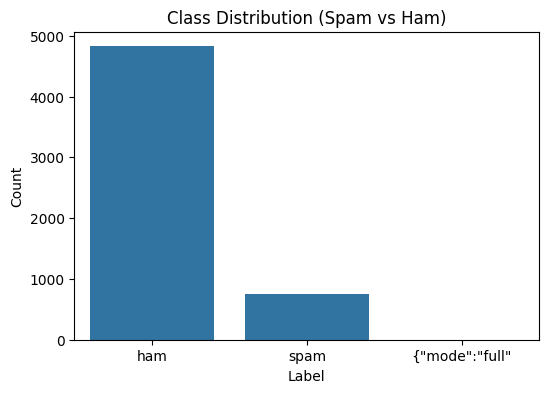

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of labels (spam vs ham)
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution (Spam vs Ham)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [19]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


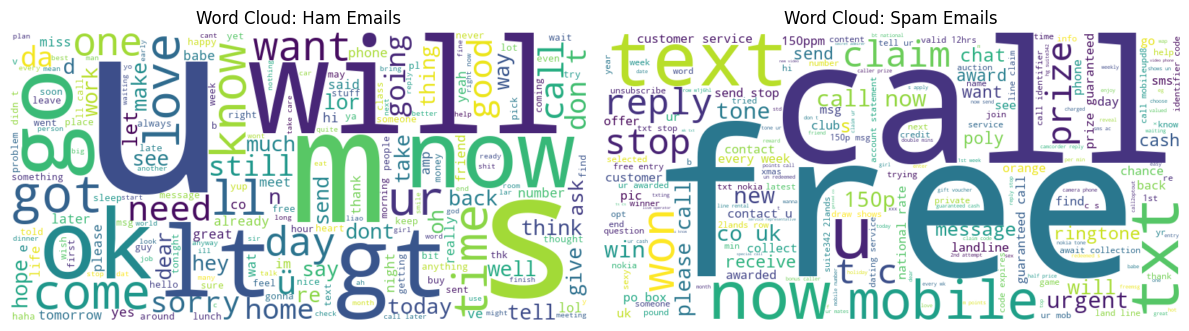

In [20]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Create a word cloud for 'ham' emails
ham_text = ' '.join(df[df['label'] == 'ham']['clean_text'])
spam_text = ' '.join(df[df['label'] == 'spam']['clean_text'])

# Generate word clouds
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_text)
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

# Plot the word clouds
plt.figure(figsize=(12, 6))

# Ham word cloud
plt.subplot(1, 2, 1)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Word Cloud: Ham Emails')
plt.axis('off')

# Spam word cloud
plt.subplot(1, 2, 2)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Word Cloud: Spam Emails')
plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm shape of split data
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(4458, 3000) (1115, 3000) (4458,) (1115,)


In [22]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Naive Bayes model
model = MultinomialNB()

# Train the model on the training data
model.fit(X_train, y_train)


MultinomialNB()

In [23]:
# Make predictions on the test data
y_pred = model.predict(X_test)


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


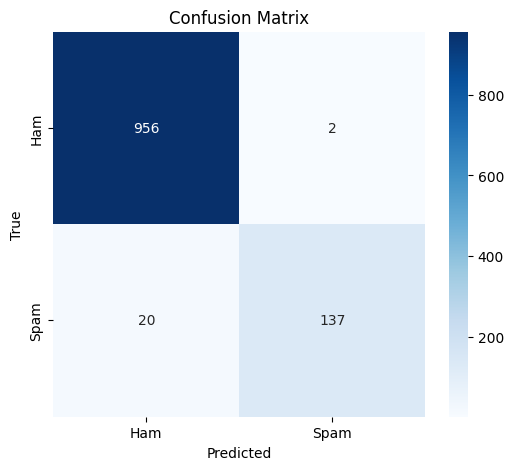

In [26]:
from sklearn.metrics import confusion_matrix


# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [27]:
from sklearn.metrics import accuracy_score


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score  # Import accuracy_score

# Create the model
model = MultinomialNB()

# Define the parameter grid
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}

# Set up the grid search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
print(f"Best hyperparameters: {grid_search.best_params_}")

# Evaluate the best model
best_model = grid_search.best_estimator_

# Predict using the best model
y_pred = best_model.predict(X_test)

# Evaluate the model performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters: {'alpha': 0.5}
Accuracy: 0.9802690582959641


In [29]:
print(y.value_counts())


label
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64


In [30]:
# Remove rows where the label is `{"mode":"full"}`
df = df[df['label'] != '{"mode":"full"}']

# Check the updated class distribution
print(df['label'].value_counts())


label
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64


In [31]:
from sklearn.utils import resample

# Separate majority and minority classes
ham = df[df['label'] == 'ham']
spam = df[df['label'] == 'spam']

# Undersample the majority class (ham)
ham_undersampled = resample(ham, 
                            replace=False,    # Do not sample with replacement
                            n_samples=len(spam),  # Match the number of spam samples
                            random_state=42)  # For reproducibility

# Combine the undersampled ham with spam
df_balanced = pd.concat([ham_undersampled, spam])

# Check the new class distribution
print(df_balanced['label'].value_counts())


label
ham     747
spam    747
Name: count, dtype: int64


In [32]:
# Oversample the minority class (spam)
spam_oversampled = resample(spam, 
                            replace=True,     
                            n_samples=len(ham),  
                            random_state=42)  

# Combine the ham with the oversampled spam
df_balanced = pd.concat([ham, spam_oversampled])

# Check the new class distribution
print(df_balanced['label'].value_counts())


label
ham     4825
spam    4825
Name: count, dtype: int64


In [33]:

X = df_balanced['clean_text']  
y = df_balanced['label']




In [34]:
from sklearn.naive_bayes import MultinomialNB

# Train the final model
final_model = MultinomialNB(alpha=0.5)
final_model.fit(X_train, y_train)

# Predict on test set
y_pred = final_model.predict(X_test)


Accuracy: 0.9802690582959641
Precision: 0.9787234042553191
Recall: 0.8789808917197452
F1 Score: 0.9261744966442953

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       958
        spam       0.98      0.88      0.93       157

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



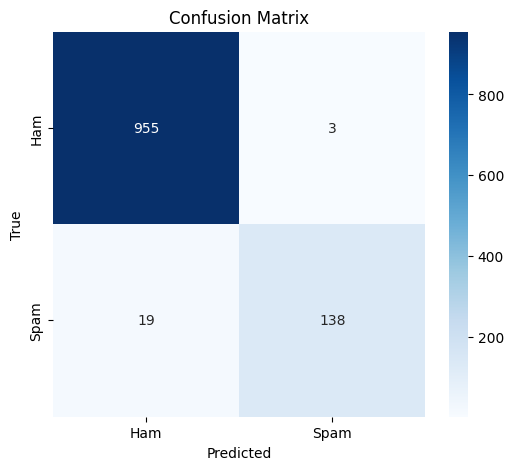

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred, pos_label='spam'))
print("F1 Score:", f1_score(y_test, y_pred, pos_label='spam'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [36]:
import joblib

# Save the model
joblib.dump(final_model, 'email_spam_classifier.pkl')

# Save the vectorizer too (so you can transform new data the same way)
joblib.dump(vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']

In [37]:
model = joblib.load('email_spam_classifier.pkl')
vectorizer = joblib.load('vectorizer.pkl')


In [38]:
# Example email
sample_email = ["Congratulations! You've won a free iPhone. Click here to claim now!"]

# Preprocess the email just like your training data
sample_vector = vectorizer.transform(sample_email)

# Predict
prediction = final_model.predict(sample_vector)
print("Prediction:", prediction[0])


Prediction: spam


In [39]:
import sqlite3

# Connect to your SQLite database
conn = sqlite3.connect('your_file.db')  # Replace with your actual database file path

# Query to list all the tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = conn.execute(query).fetchall()

# Print all table names
print("Tables in the database:", tables)

# Close connection
conn.close()


Tables in the database: []


In [40]:
import sqlite3
import pandas as pd

# Connect to your SQLite database
conn = sqlite3.connect('your_file.db')  # Replace with the correct path to your .db file

# Query to list all the tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = conn.execute(query).fetchall()

# Print all table names to check if your table exists
print("Tables in the database:", tables)

# If sms_data exists, you can now load it into a DataFrame
if ('sms_data',) in tables:
    df = pd.read_sql_query("SELECT * FROM sms_data", conn)
    print(df.head())
else:
    print("sms_data table does not exist!")

# Close the connection after everything is done
conn.close()


Tables in the database: []
sms_data table does not exist!


In [41]:
import os
print(os.path.abspath('sms_db.db'))  # Replace with your actual db file path


d:\anacondo\emailclaf\sms_db.db


In [42]:
import sqlite3
import pandas as pd

# 1. Connect to sms_data.db (will be created if not exists)
conn = sqlite3.connect('sms_data.db')

# 2. Create table if it doesn't exist
conn.execute('''
CREATE TABLE IF NOT EXISTS sms_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    text TEXT NOT NULL,
    label TEXT NOT NULL
)
''')

# 3. Insert sample data
sample_data = [
    ("Congratulations! You've won a free ticket to Bahamas. Text WIN to 8888!", "spam"),
    ("Are we still on for coffee later today?", "ham"),
    ("URGENT! Call this number to claim your prize.", "spam"),
    ("Good morning! Just checking in.", "ham")
]

conn.executemany("INSERT INTO sms_data (text, label) VALUES (?, ?)", sample_data)
conn.commit()

# 4. Read the data from sms_data
df = pd.read_sql_query("SELECT * FROM sms_data", conn)

# 5. Print out the results
print("📥 Data from sms_data table:")
print(df)

conn.close()


📥 Data from sms_data table:
   id                                               text label
0   1  Congratulations! You've won a free ticket to B...  spam
1   2            Are we still on for coffee later today?   ham
2   3      URGENT! Call this number to claim your prize.  spam
3   4                    Good morning! Just checking in.   ham
4   5  Congratulations! You've won a free ticket to B...  spam
5   6            Are we still on for coffee later today?   ham
6   7      URGENT! Call this number to claim your prize.  spam
7   8                    Good morning! Just checking in.   ham


In [50]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('sms_data.db')
df = pd.read_sql_query("SELECT * FROM sms_data", conn)
conn.close()


In [43]:
X = df['text']     # messages
y = df['label']    # 'spam' or 'ham'


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [47]:
train_test_split(X, y, test_size=0.2)


[0    Congratulations! You've won a free ticket to B...
 6        URGENT! Call this number to claim your prize.
 5              Are we still on for coffee later today?
 1              Are we still on for coffee later today?
 4    Congratulations! You've won a free ticket to B...
 3                      Good morning! Just checking in.
 Name: text, dtype: object,
 2    URGENT! Call this number to claim your prize.
 7                  Good morning! Just checking in.
 Name: text, dtype: object,
 0    spam
 6    spam
 5     ham
 1     ham
 4    spam
 3     ham
 Name: label, dtype: object,
 2    spam
 7     ham
 Name: label, dtype: object]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2, random_state=42)


In [50]:
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")


X_test shape: (2,)
y_test shape: (2,)
y_pred shape: (1115,)


In [51]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)


X_test shape: (2,)
y_test shape: (2,)
y_pred shape: (1115,)


In [52]:
from sklearn.feature_extraction.text import CountVectorizer

# Assuming you have already fitted the vectorizer on the training data
vectorizer = CountVectorizer()

# Fit on your training data and transform the test data (if not done yet)
X_train_transformed = vectorizer.fit_transform(X_train)  # Fit on training data
X_test_transformed = vectorizer.transform(X_test)        # Transform test data

# Now X_test_transformed can be passed to the model for predictions


In [53]:
from sklearn.feature_extraction.text import CountVectorizer

# Fit the vectorizer on the training data
vectorizer = CountVectorizer()

# Transform the training data (X_train)
X_train_transformed = vectorizer.fit_transform(X_train)

# Transform the test data (X_test) using the already fitted vectorizer
X_test_transformed = vectorizer.transform(X_test)

# Now check the shape of the transformed data
print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")


X_train_transformed shape: (6, 23)
X_test_transformed shape: (2, 23)


In [54]:
print(f"Training data shape: {X_train_transformed.shape}")
print(f"Test data shape: {X_test_transformed.shape}")


Training data shape: (6, 23)
Test data shape: (2, 23)


In [55]:
model.fit(X_train_transformed, y_train)


MultinomialNB()

In [56]:
print(X_test.shape)
print(y_test.shape)
print(y_pred.shape)


(2,)
(2,)
(1115,)


In [58]:
print(f"X_test shape: {X_test.shape}")



X_test shape: (2,)


In [70]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the vectorizer
vectorizer = CountVectorizer()

# Fit and transform the training data (X_train)
X_train_vectorized = vectorizer.fit_transform(X_train)

# Transform the test data (X_test) using the same vectorizer
X_test_vectorized = vectorizer.transform(X_test)

# Train your model using the vectorized training data
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

# Predict on the vectorized test data
y_pred = model.predict(X_test_vectorized)

# Now, y_pred can be compared with y_test, as both are compatible
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.0
Classification Report:
              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       2.0
        spam       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [60]:
print("Training data label distribution:", y_train.value_counts())
print("Testing data label distribution:", y_test.value_counts())


Training data label distribution: label
spam    4
ham     2
Name: count, dtype: int64
Testing data label distribution: label
ham    2
Name: count, dtype: int64


In [62]:
from sklearn.feature_extraction.text import CountVectorizer

# Assuming you have text data in X_train and X_test
vectorizer = CountVectorizer()

# Fit the vectorizer on the training data and transform both training and test data
X_train_vectorized = vectorizer.fit_transform(X_train)  # Fit and transform on the training data
X_test_vectorized = vectorizer.transform(X_test)  # Only transform on the test data

# Now print the shapes
print("X_train shape after vectorization:", X_train_vectorized.shape)
print("X_test shape after vectorization:", X_test_vectorized.shape)


X_train shape after vectorization: (6, 23)
X_test shape after vectorization: (2, 23)


In [63]:
print("Predictions:", y_pred)


Predictions: ['ham' 'ham' 'ham' ... 'ham' 'ham' 'spam']


In [64]:
model = MultinomialNB(alpha=0.5)  # You can try adjusting alpha or other parameters.
model.fit(X_train_vectorized, y_train)


MultinomialNB(alpha=0.5)

In [65]:
# Assuming y_test and y_pred are pandas Series or numpy arrays
for i in range(len(y_test)):
    print(f"Actual: {y_test.iloc[i] if isinstance(y_test, pd.Series) else y_test[i]}, Predicted: {y_pred[i]}")


Actual: ham, Predicted: ham
Actual: ham, Predicted: ham


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create and configure the vectorizer
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=3000)

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = vectorizer.transform(X_test)


In [67]:
# Check class distribution in the training set
print(y_train.value_counts())


label
spam    4
ham     2
Name: count, dtype: int64


In [68]:
from sklearn.naive_bayes import MultinomialNB

# If you want the model to learn the class priors automatically, leave class_prior as None
model = MultinomialNB(class_prior=None)  # or class_prior='uniform'

# Fit the model
model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Evaluate performance
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       2.0
        spam       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [69]:
from sklearn.naive_bayes import MultinomialNB

# If you want the model to learn the class priors automatically, leave class_prior as None
model = MultinomialNB(class_prior=None)  # or class_prior='uniform'

# Fit the model
model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Evaluate performance
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         ham       0.00      0.00      0.00       2.0
        spam       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [70]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'spam_classifier_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [75]:
joblib.dump(model, 'spam_model.pkl')


['spam_model.pkl']

In [76]:
model = joblib.load('spam_model.pkl')


In [78]:
import os
import joblib

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Now save the model
joblib.dump(model, 'models/spam_model.pkl')


['models/spam_model.pkl']

In [80]:
import os
import joblib

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Example model (assuming 'model' is your trained model)
# model = ...

# Save the model in the 'models' directory
joblib.dump(model, 'models/spam_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [81]:
model = joblib.load('models/spam_model.pkl')


In [82]:
new_message = ["Hey, let's catch up for coffee tomorrow."]
new_message_vectorized = vectorizer.transform(new_message)  # assuming you used CountVectorizer or TfidfVectorizer
prediction = model.predict(new_message_vectorized)
print("Prediction:", prediction)


Prediction: ['spam']
